In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [12]:
from sklearn.metrics import (
        classification_report,
        confusion_matrix,
        roc_auc_score,
        roc_curve,
        precision_recall_curve
        )

In [13]:
# Load DataSet

In [14]:
data = pd.read_csv("creditcard.csv")

In [15]:
print("Dataset Loaded. Shape:", data.shape)

Dataset Loaded. Shape: (284807, 31)


In [16]:
# Data Exploration

In [17]:
print(data.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [18]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [19]:
print(data.describe())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1.332271e+00  1.23709

In [20]:
# Class Disribution

In [21]:
fraud_count = data['Class'].value_counts()

In [22]:
print("\nClass Distribution:\n", fraud_count)


Class Distribution:
 Class
0    284315
1       492
Name: count, dtype: int64


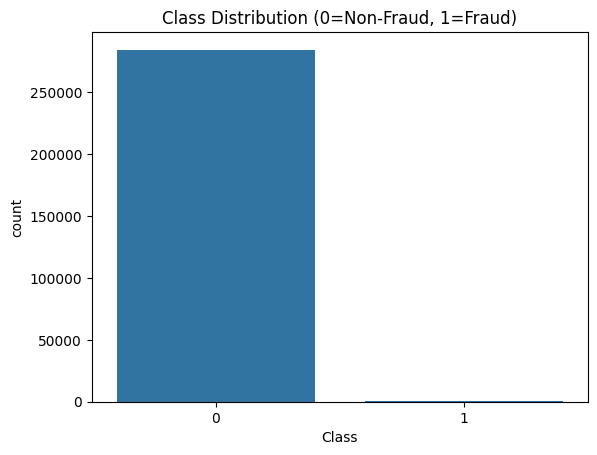

In [23]:
sb.countplot(x='Class', data=data)
plt.title('Class Distribution (0=Non-Fraud, 1=Fraud)')
plt.show()

In [24]:
# Missing Values

In [25]:
print("\nMissing Values:\n", data.isnull().sum())


Missing Values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [26]:
# Data Processing

In [27]:
scaler = StandardScaler()
data['normAmount'] = scaler.fit_transform(data[['Amount']])
data['normTime'] = scaler.fit_transform(data[['Time']])

In [28]:
data.drop(['Time', 'Amount'], axis=1, inplace=True)

In [29]:
# Transaction Amount Analysis by Class

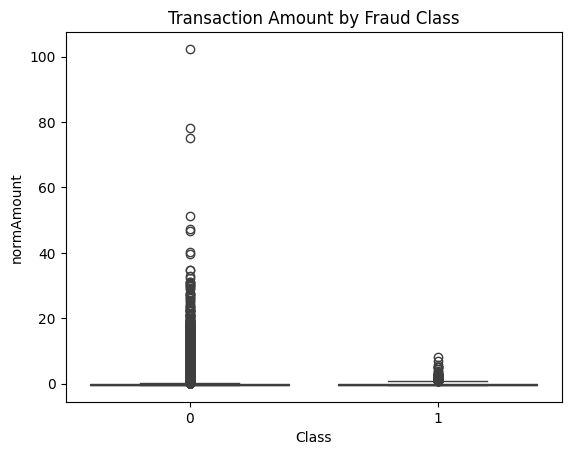

In [30]:
sb.boxplot(x='Class', y='normAmount', data=data)
plt.title("Transaction Amount by Fraud Class")
plt.show()

In [31]:
# Fraud Pattern by Hour

In [32]:
data['Hour'] = (data['normTime'] * data.shape[0] * 30) // 3600 % 24

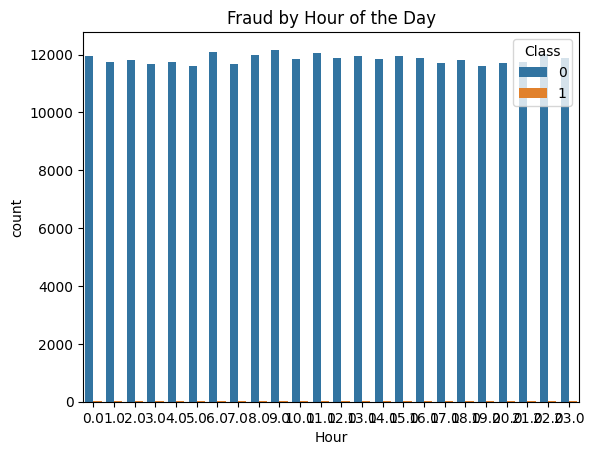

In [33]:
sb.countplot(x='Hour', hue='Class', data=data)
plt.title("Fraud by Hour of the Day")
plt.show()

In [34]:
# Heatmap - Correlation

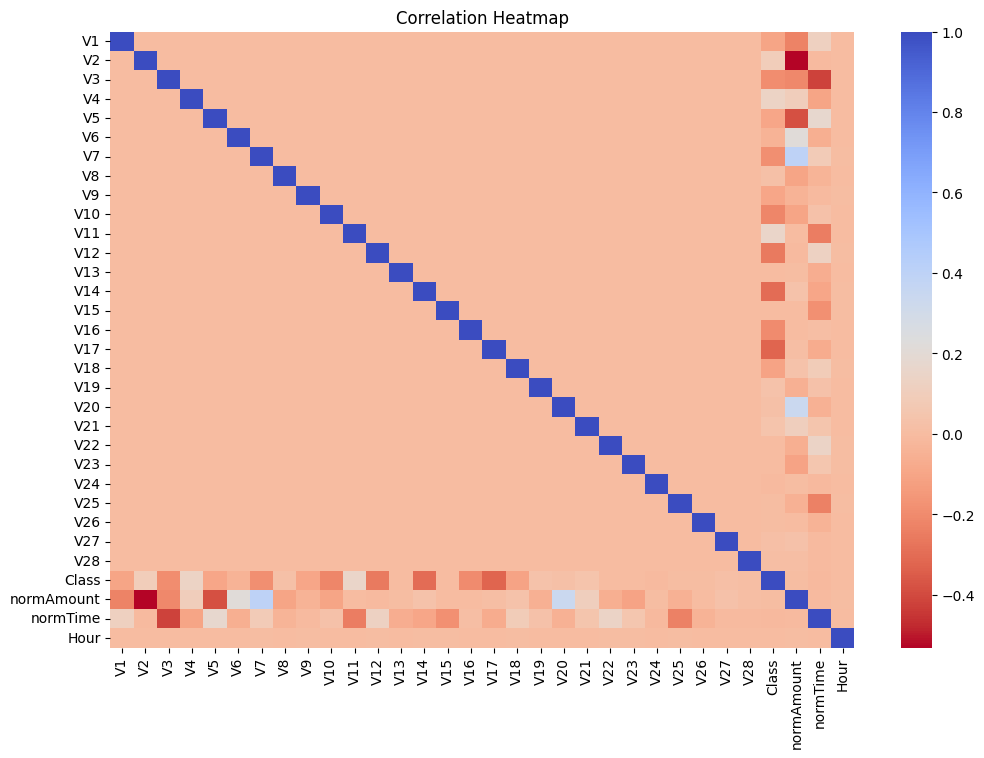

In [35]:
plt.figure(figsize=(12, 8))
sb.heatmap(data.corr(), cmap="coolwarm_r", annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [36]:
# Split : Train - Test

In [37]:
x = data.drop('Class', axis=1)
y = data['Class']

In [38]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

In [39]:
# Model 1: Logistic Regression

In [40]:
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [41]:
y_pred_lr = lr.predict(x_test)
y_proba_lr = lr.predict_proba(x_test)[:, 1]

In [42]:
print("\n Logistic Regression")
print(classification_report(y_test, y_pred_lr))


 Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [43]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_lr))

Confusion Matrix:
 [[56851    13]
 [   36    62]]
ROC AUC Score: 0.9579230573771434


In [44]:
# Results for Logistic Regression

In [45]:
report = classification_report(y_test, y_pred_lr, output_dict=True)

In [46]:
precision_1 = report['1']['precision']
recall_1 = report['1']['recall']

In [47]:
f1_1 = report['1']['f1-score']
support_1 = report['1']['support']
support_0 = report['0']['support']

In [48]:
accuracy = (y_pred_lr == y_test).mean()

In [49]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lr).ravel()
roc_auc = roc_auc_score(y_test, lr.predict_proba(x_test)[:, 1])

In [50]:
print(f"\nDescriptive Logistic Regression Evaluation:\n")
print(f"Precision for class 1 (fraud) ~{precision_1:.2f} means out of all predicted frauds, {precision_1*100:.0f}% were actually fraud.\n")
print(f"Recall for class 1 ~{recall_1:.2f} means it correctly detects {recall_1*100:.0f}% of actual frauds — not perfect but decent given the imbalance.\n")
print(f"F1-score ~{f1_1:.2f} balances precision and recall.\n")
print(f"Support: {support_1:.0f} fraud cases in test, {support_0:.0f} non-fraud.\n")
print(f"Accuracy ~{accuracy:.2f} — high, but expected due to class imbalance (most transactions are non-fraud).\n")
print(f"Confusion Matrix shows most non-fraud correctly identified ({tn}), {fp} false positives, {fn} false negatives, {tp} true positives.\n")
print(f"ROC AUC ~{roc_auc:.3f} — strong overall classification power.\n")


Descriptive Logistic Regression Evaluation:

Precision for class 1 (fraud) ~0.83 means out of all predicted frauds, 83% were actually fraud.

Recall for class 1 ~0.63 means it correctly detects 63% of actual frauds — not perfect but decent given the imbalance.

F1-score ~0.72 balances precision and recall.

Support: 98 fraud cases in test, 56864 non-fraud.

Accuracy ~1.00 — high, but expected due to class imbalance (most transactions are non-fraud).

Confusion Matrix shows most non-fraud correctly identified (56851), 13 false positives, 36 false negatives, 62 true positives.

ROC AUC ~0.958 — strong overall classification power.



In [51]:
# Random Forest Classifier

In [52]:
from sklearn.ensemble import RandomForestClassifier

In [57]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [63]:
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
y_proba_rf = rf.predict_proba(x_test)[:, 1]

In [65]:
print("\n Random Forest ")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_rf))


 Random Forest 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.81      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
 [[56859     5]
 [   19    79]]
ROC AUC Score: 0.9578362946895134


In [66]:
# ROC Curve Comparison

In [67]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

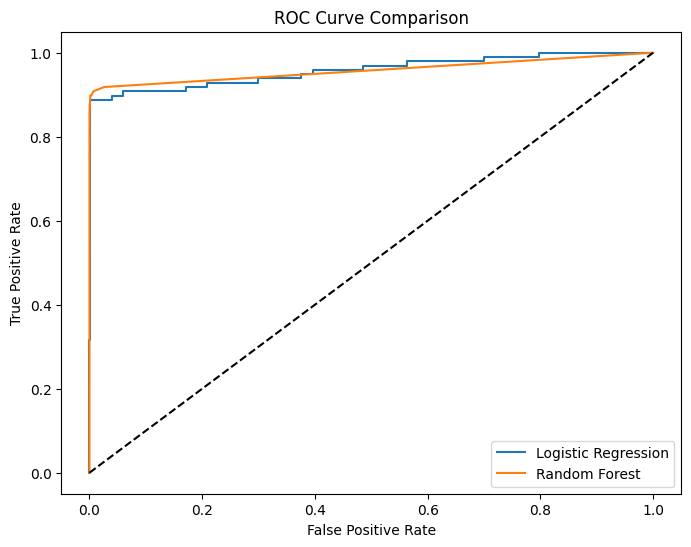

In [68]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [69]:
# Precision-Recall Curve (Random Forest)

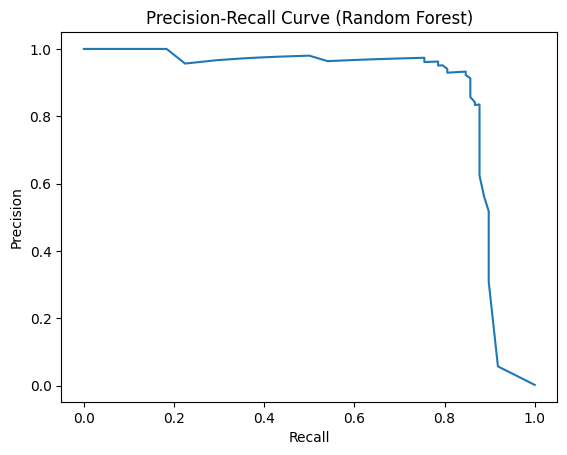

In [70]:
precision, recall, _ = precision_recall_curve(y_test, y_proba_rf)
plt.plot(recall, precision)
plt.title("Precision-Recall Curve (Random Forest)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

In [71]:
# Confusion Matrix as Heatmap (Random Forest)

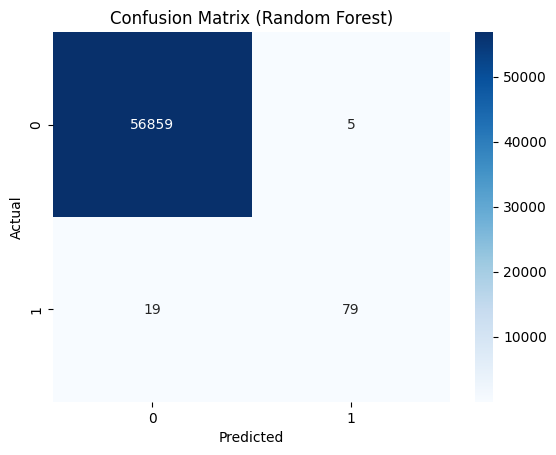

In [73]:
cm = confusion_matrix(y_test, y_pred_rf)
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [74]:
# Feature Importance (Random Forest)

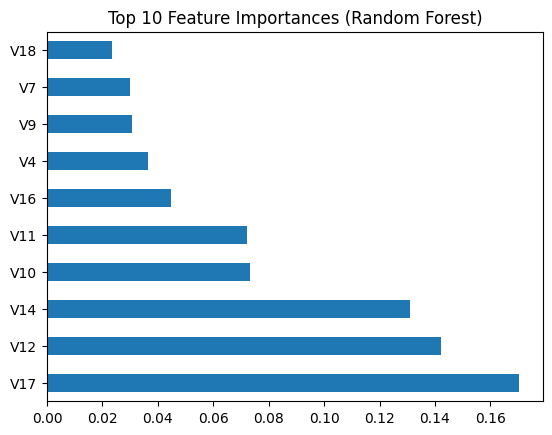

In [76]:
feat_importances = pd.Series(rf.feature_importances_, index=x.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()

In [77]:
# Summary

In [78]:
print("\nSUMMARY:")
print("• Dataset is highly imbalanced (fraudulent transactions ≈ 0.17%)")
print("• Both Logistic Regression and Random Forest performed well with ROC AUC > 0.90")
print("• Random Forest showed better recall — critical for fraud detection")
print("• Precision-Recall curve and confusion matrix give better insights for imbalanced data")
print("• Top features (V-values) identified by Random Forest can inform further feature engineering")


SUMMARY:
• Dataset is highly imbalanced (fraudulent transactions ≈ 0.17%)
• Both Logistic Regression and Random Forest performed well with ROC AUC > 0.90
• Random Forest showed better recall — critical for fraud detection
• Precision-Recall curve and confusion matrix give better insights for imbalanced data
• Top features (V-values) identified by Random Forest can inform further feature engineering
